In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_price = pd.read_csv("../data/processed/cleaned_eth_price.csv")
df_post = pd.read_csv("../data/processed/cleaned_eth_post.csv")



In [2]:
print(df_post['score'].max())
print(df_post['score'].min())
print(df_post.head())

2507
-314
   created_utc subreddit                                               body  \
0   1579408968  ethereum    yeah that s infallible logic you re using there   
1   1579408860  ethereum                                 remindme  6 months   
2   1579408651  ethereum    thats what people said here about 2018 and 2019   
3   1579408630  ethereum  my comment is 100  accurate    according to th...   
4   1579407990  ethereum  risk of a smart contract being hacked  if ther...   

   score        Date  vader_scores  
0      6  2020-01-19        0.2960  
1      3  2020-01-19        0.0000  
2     -5  2020-01-19        0.0000  
3    -13  2020-01-19       -0.2023  
4      2  2020-01-19        0.2732  


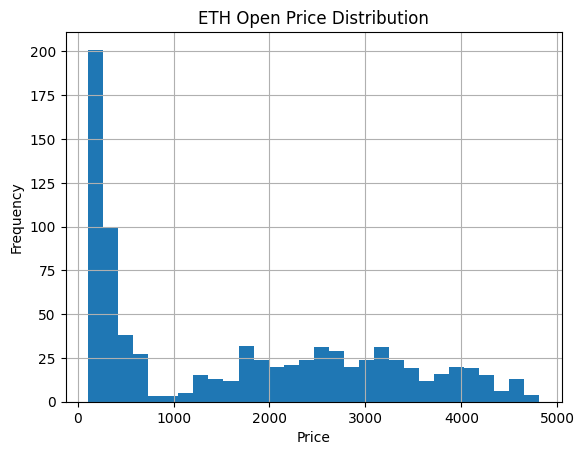

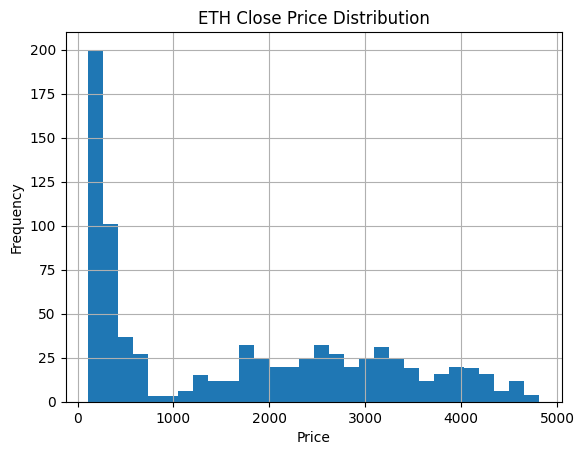

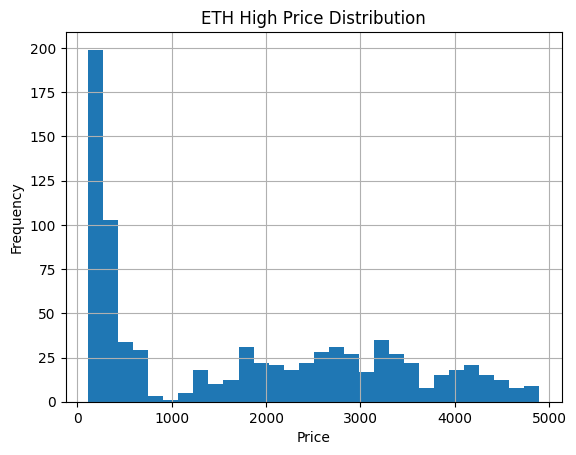

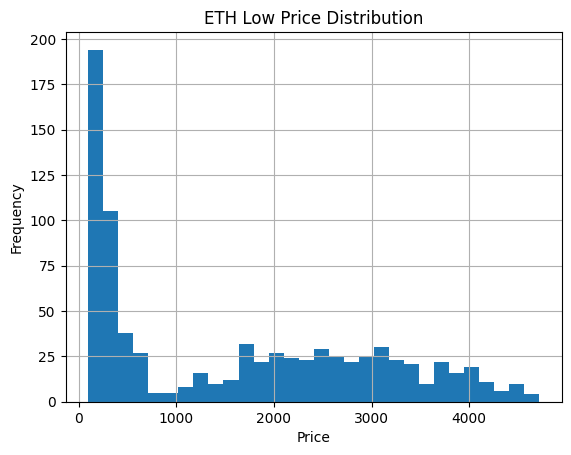

In [3]:
# Histo Analysis of df_price
df_price['Open'].astype(float).hist(bins=30)
plt.title('ETH Open Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Close'].astype(float).hist(bins=30)
plt.title('ETH Close Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['High'].astype(float).hist(bins=30)
plt.title('ETH High Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Low'].astype(float).hist(bins=30)
plt.title('ETH Low Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()




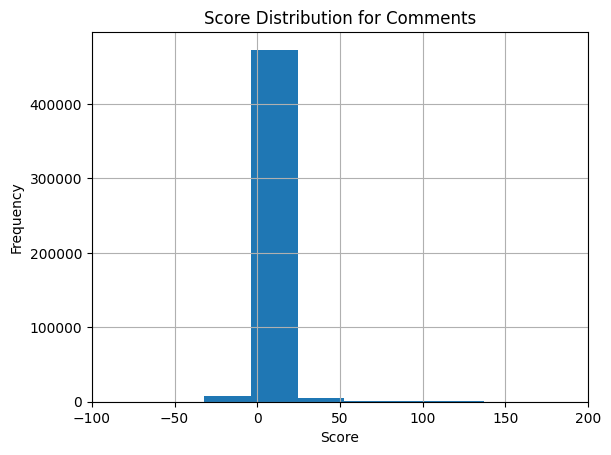

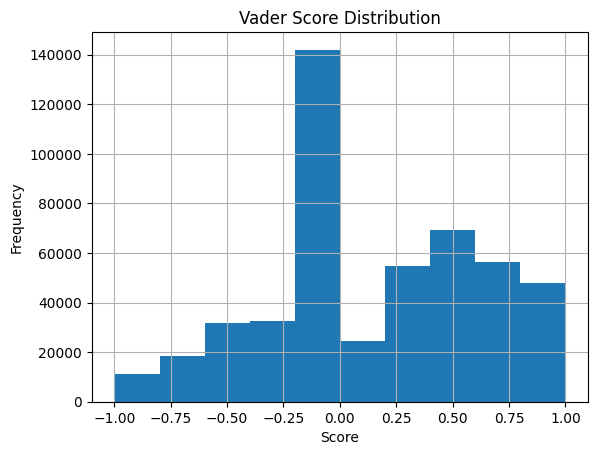

In [4]:
# Histo Analysis of df_post

df_post["score"].hist(bins=100)
plt.title("Score Distribution for Comments")
plt.xlabel("Score")
plt.xlim(-100, 200)
plt.ylabel("Frequency")
plt.show()

# Most score in range ~-10 to 25

df_post["vader_scores"].hist(bins=10)
plt.title("Vader Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


Sample positive posts:
12    with 32 eth you can be a  staker  in the new e...
13    but at the same time  don t cry about the rich...
21    gt  whether or not the communities want it is ...
24    if you have under 32 you have no option but to...
38                           that s good advice  thanks
Name: body, dtype: str
Sample negative posts:
22    the first phase of eth2 goes live this year   ...
23                                         no one cares
37    there are no staking rewards in ethereum  try ...
50    this is such a deceptive video thumbnail  i ju...
59                      and craig wright is just stupid
Name: body, dtype: str


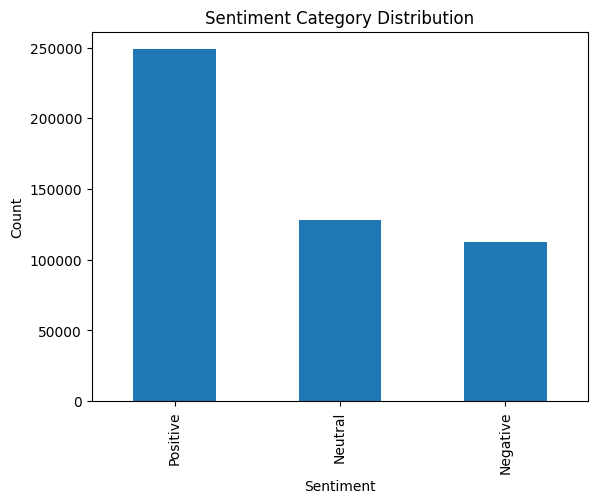

In [5]:
# Compare posts with highly positive and highly negative scores
positive_posts = df_post[df_post['vader_scores'] > 0.5]
negative_posts = df_post[df_post['vader_scores'] < -0.5]
print('Sample positive posts:')
print(positive_posts['body'].head())
print('Sample negative posts:')
print(negative_posts['body'].head())

# Group and visualize sentiment categories
def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_post['sentiment_category'] = df_post['vader_scores'].apply(categorize_sentiment)
sentiment_counts = df_post['sentiment_category'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


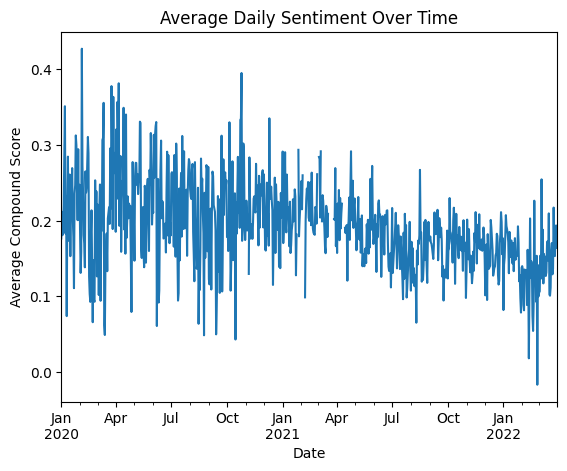

In [9]:
df_post['created_utc'] = pd.to_datetime(df_post['created_utc'], unit='s')
df_post.set_index('created_utc', inplace=True)
df_post.resample('D')['vader_scores'].mean().plot()
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Compound Score')
plt.show()

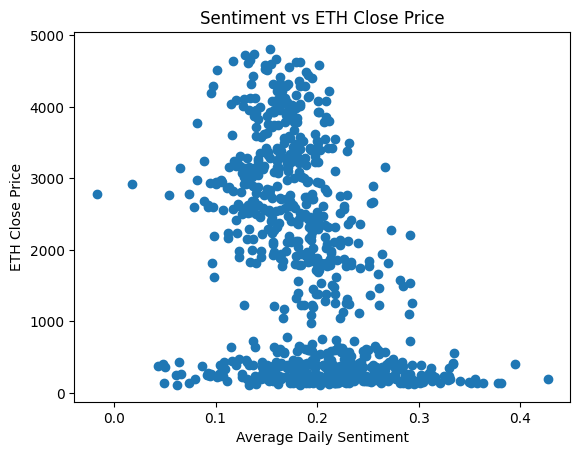

In [10]:
#  Correlate sentiment with ETH price
df_post['date'] = df_post.index.date
daily_sentiment = df_post.groupby('date')['vader_scores'].mean().reset_index()
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.date
merged = pd.merge(daily_sentiment, df_price, left_on='date', right_on='Date')
plt.scatter(merged['vader_scores'], merged['Close'].astype(float))
plt.title('Sentiment vs ETH Close Price')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('ETH Close Price')
plt.show()

Correlation between average daily sentiment and ETH close price: -0.4135


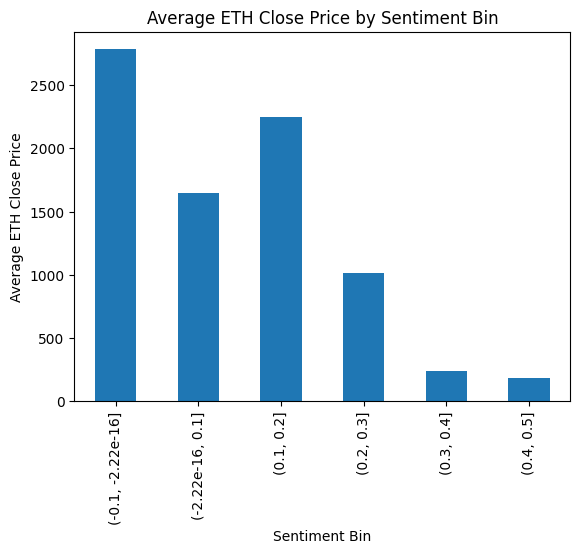

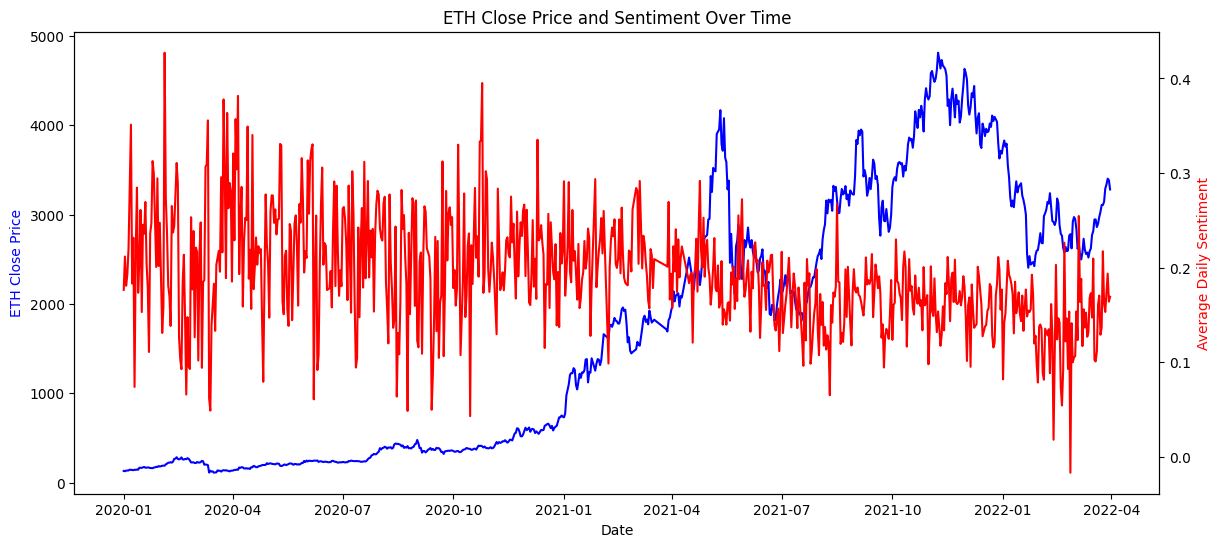

In [11]:
# Calculate correlation coefficient between sentiment and ETH close price
correlation = merged['vader_scores'].corr(merged['Close'].astype(float))
print(f'Correlation between average daily sentiment and ETH close price: {correlation:.4f}')

# Group sentiment into bins and plot average ETH price for each bin
import numpy as np
merged['sentiment_bin'] = pd.cut(merged['vader_scores'], bins=np.arange(-1, 1.1, 0.1))
avg_price_by_bin = merged.groupby('sentiment_bin')['Close'].mean()
avg_price_by_bin.plot(kind='bar')
plt.title('Average ETH Close Price by Sentiment Bin')
plt.xlabel('Sentiment Bin')
plt.ylabel('Average ETH Close Price')
plt.show()

# Overlay ETH price and sentiment trends over time
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged['date'], merged['Close'], color='blue', label='ETH Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('ETH Close Price', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged['date'], merged['vader_scores'], color='red', label='Average Daily Sentiment')
ax2.set_ylabel('Average Daily Sentiment', color='red')
plt.title('ETH Close Price and Sentiment Over Time')
plt.show()

KeyError: "['return'] not in index"